# Building A Neural Net From Scratch

For this lab, I will be following along with [Andrej's Video](https://www.youtube.com/watch?v=VMj-3S1tku0) as he walks through how to build micrograd which is used in the backpropagation step in training neural networks.


### The Gradient
To start the video, Andrej reviews the idea of derivatives of multivariable functions in the context of computing. This is an important idea because to minimize the loss function, we will find the gradient of the loss function with respect to the weights of the neurons.

Then the weights can be adjusted to minimize the loss function.

#### The Value Object
To start Andrej start by defining his own value class


In [ ]:
import math
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self._prev = set(_children)
    self._op = _op # the op that produced this node, for graphviz / debugging / etc
    self.label = label
    self.grad = 0.0
    self._backward = lambda: None

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    n = Value(self.data + other.data, (self, other), '+')
    def _backward():
      self.grad += 1.0 * n.grad
      other.grad += 1.0 * n.grad
    n._backward = _backward
    return n

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    n = Value(self.data * other.data, (self, other), '*')
    def _backward():
      self.grad += other.data * n.grad
      other.grad += self.data * n.grad
    n._backward = _backward
    return n

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    n = Value(self.data**other, (self,), f'**{other}')
    def _backward():
      self.grad += (other * self.data**(other-1)) * n.grad
    n._backward = _backward
    return n

  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

  def __rsub__(self, other): # other - self
    return other + (-self)

  def exp(self):
    n = Value(math.exp(self.data), (self, ), 'exp')
    def _backward():
      self.grad += n.data * n.grad
    n._backward = _backward
    return n

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    n = Value(t, (self, ), 'tanh')
    def _backward():
      self.grad += (1 - t**2) * n.grad
    n._backward = _backward
    return n

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

The repr function is a predefined python function that prints the value and it's attributes. He just decided to make a custom representation here. This is just to get a nice print output make it easier to tell whats going on.

He then outlines some basic operations that the value object can carry out.

The value object has the attribute previous, which is a pointer to a set of its children, building a tree like data structure. I can see how this will be used when representing the chain of operatins required to backpropagate the gradient.

Any time there is an operation between multiple value objects, the result, the parent, now is linked to the children who combined formed the parent.

In [ ]:
# Example usage of Value obj
a = Value(2, label='a')
b = Value(3, label='b')
c = Value(-1, label='c')
d = b*c; d.label='d'
e = a+d; e.label='e'
f = Value(-2, label='f')
L = e*f; L.label='L'
print(d._prev)
# Note that the children set is the addition of two nodes instead
# of the multiplication then sum

{Value(data=3), Value(data=-1)}


#### Graph Visualization
To provide a visualization of the operations Andrej provides some code to do so.

In [ ]:
from graphviz import Digraph

def trace(root):

  nodes,edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes,edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      dot.node(name = uid + n._op, label = n._op)
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

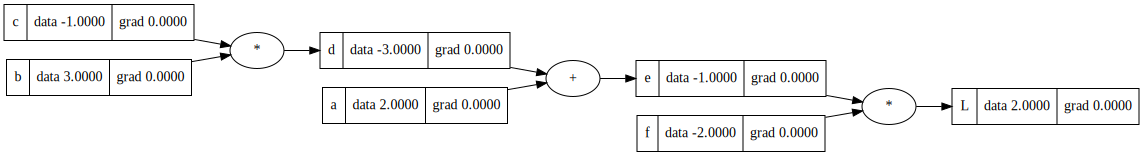

In [ ]:
draw_dot(L)

We then include an attribute, grad which represent the gradient of the output, the loss function with respect to that value. Originally, they are set to zero meaning that they have no affect on the gradient of the output.

**Question** Why do we assume that the weights have no affect on the gradient at the start? Would it skew our later calculations?


The derivative of the output node is always 1 so we can set that manually

In [ ]:
L.grad = 1.0

Andrej then provided some intution of what the backpropagated gradient would look like for this simple expression. Working backwards from the output L, we find the derivatives of the functions composing L.

In this case, L = e *f, so dL/de = f, and dL/df = e. This pattern follows for all multlication nodes.

For the preceeding addition node e = a + d, the derivative of e with respect to either variable is just 1. So de/da = 1. Then using the chain rule to backpropagate the gradient dL/da = dL/de * de/da = f * 1.

This recursive application of chain rule is the whole backpropagation algorithm.
First find local derivatives, then multiply by chain ruled derivatives to get to dL, and continue untill the start is reached.

#### Automating Backpropagation
We want the graph to be able to calculate its own gradients instead of doing it by hand and manually assigning it.

So, we create a _backwards function that implements a function bases on if it is an addition, multiplication, or activation step.

The backwards function is only valid for nodes that have had their gradients previously found, otherwise it will just end up being zero, so when backpropagating through a network, we need to traverse the graph in a way that we have always calculated all of the dependent gradients before moving to its children.

To do so we have to order the graph topologically. We can do this by starting from the output node, then going through each child. When we inspect each child, we then go through there dependencies and append them to the graph. This depth first search ensures that the graph is traversed in top down order.

**Question** How do you backpropagate through graphs that feedback later data into earlier nodes? E.G. what about graphs that cannot be traversed from left to right?



In [ ]:
L.backward()

Andrej then pointed out a bug in the code where if any node was used in more than one calculation, since we are reseting the gradient of the node each time we find the gradient, we loose data.

To fix this, if we think of a multivariable function, f(x,y,z) = xy + y + z
and I was interested in partial f/ partial y, I would find that it is f_y = x + 1 which is the sum of the gradients of the individual terms. So, for each term we need to accumulate the gradients.


To allow us to work with numbers that are not value objects we do a little workaround that casts the numbers to value objects when we do operations.

Suprisingly, pytorch works effectivley the same but with much more accelerated optimizations and instead of value objects, all elements are tensors.

### Creating A Neuron

The next step here in making the neural network is to make the individual neurons that comprise the network.

A simple Neuron class that he made looks like this

In [ ]:
import random
class Neuron:

  def __init__(self, nin):

    # Initializes the weights to random numebers
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):

    # The zip function combines two iterators into one making a bunch of pairs
    # Here the nin (number of inputs) is equal to the number of weights
    # this single line of code sums the producst of wi xi with b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

x = [-1.0, 1.0, 5]
n = Neuron(2)
n(x)

Value(data=0.8529574014349971)

Then to represent a layer of neurons, we order them like so

In [ ]:
class Layer:

  def __init__(self, nin, nout):
    # Creates a neuron with number of inputs nin for each out desired (nout)
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    # Since there is multiple neurons in a layer, there will be multilple outputs
    # All of the outputs are compiled into an array
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

The again adding together all of the layers of abstraction into a single simple forward network

In [ ]:
class MLP:

  def __init__(self, nin, nouts):

    # The nin (number of inputs) into the neural network
    # is made into an array which is added to nouts. This ensures the input layer is made
    sz = [nin] + nouts

    # Attribute representing the layers inside of the network
    # The width of the array nouts defines the depth (number of layers) in the net
    # Each element in the array sz defines the number of inputs to the layer
    # to match the number of outputs to the number of inputs to the next layer, sz[i+1]
    # To prevent out of bounds len(nouts) is used and not sz
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

### Training The Neural Net
Now that we have the infastructure for a neural network in place, we now have to be able to tune the weights of the network to make accurate predcitions.

To do so, we define a function that describes how good the neural network is at making predictions called the loss function. The closer to zero the loss function is, the more accurate the neural net. This is why we spent so much time finding the gradient of the network so that we can determine which direction to shift the weights of the neural net to minimize the loss function.

For Andrej's example he uses the loss function being the root mean square error which is used for gaussian distributions.

$$\mathbb{L}= \sum (y_{pred} - y_{actual})^2$$


Now what we do, since we know the gradients of each weight with respect to the loss function, we can tune weights in the direction of the negative gradient so that we are minimizing the loss function

$$\nabla\mathbb{L}$$


## Final Code

In [ ]:

epochs = 10
learning_rate = 0.05
for k in range(epochs):
  # ouputs predicted by the NN (forward pass)
  ypred = [n(x) for x in xs]
  # define the loss function
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  # Where the gradients are calculated and weights are adjusted to minimize the grad
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  # update the weights
  for p in n.parameters():
    p.data += -1 * learning_rate * p.grad
  print(k, loss.data)

0 13.341681410387778
1 12.778454836191798
2 10.730041992208857
3 9.093008520087098
4 8.39068605830742
5 9.730989268270053
6 8.605259345983436
7 9.220551476656619
8 9.658281487988575
9 8.32578654407328


In [ ]:
import math

class Value:
  ## A scalar value class that supports automatic differentiation.
  #
  #  Each Value object represents a node in a computational graph.
  #  Operations between Value objects construct the graph, and calling
  #  backward() performs reverse-mode automatic differentiation to
  #  compute gradients.
  #
  #< @brief Scalar value with automatic differentiation support.

  def __init__(self, data, _children=(), _op='', label=''):
    ## Constructor for Value class.
    #
    #< @param data The numeric value stored in this node.
    #< @param _children A set of parent nodes that produced this node.
    #< @param _op The operation that produced this node (e.g. '+', '*', etc.).
    #< @param label Optional label for graph visualization or debugging.
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self.grad = 0.0
    self._backward = lambda: None

  def __repr__(self):
    ## Return a string representation of this Value.
    #< @brief String representation for debugging.
    return f"Value(data={self.data})"

  def __add__(self, other):
    ## Add this Value to another.
    #
    #< @param other The other Value or numeric constant.
    #< @return A new Value representing the sum.
    other = other if isinstance(other, Value) else Value(other)
    n = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * n.grad
      other.grad += 1.0 * n.grad
    n._backward = _backward
    return n

  def __mul__(self, other):
    ## Multiply this Value by another.
    #
    #< @param other The other Value or numeric constant.
    #< @return A new Value representing the product.
    other = other if isinstance(other, Value) else Value(other)
    n = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * n.grad
      other.grad += self.data * n.grad
    n._backward = _backward
    return n

  def __pow__(self, other):
    ## Raise this Value to a constant power.
    #
    #< @param other Exponent (int or float).
    #< @return A new Value representing self**other.
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    n = Value(self.data**other, (self,), f'**{other}')

    def _backward():
      self.grad += (other * self.data**(other-1)) * n.grad
    n._backward = _backward
    return n

  def __rmul__(self, other):
    ## Right-hand multiplication support.
    #< @brief Implements other * self.
    return self * other

  def __truediv__(self, other):
    ## Division operation.
    #< @brief Implements self / other.
    return self * other**-1

  def __neg__(self):
    ## Unary negation operator.
    #< @brief Implements -self.
    return self * -1

  def __sub__(self, other):
    ## Subtraction operation.
    #< @brief Implements self - other.
    return self + (-other)

  def __radd__(self, other):
    ## Right-hand addition support.
    #< @brief Implements other + self.
    return self + other

  def __rsub__(self, other):
    ## Right-hand subtraction support.
    #< @brief Implements other - self.
    return other + (-self)

  def exp(self):
    ## Exponential function.
    #< @return A new Value representing exp(self).
    n = Value(math.exp(self.data), (self,), 'exp')

    def _backward():
      self.grad += n.data * n.grad
    n._backward = _backward
    return n

  def tanh(self):
    ## Hyperbolic tangent function.
    #< @return A new Value representing tanh(self).
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    n = Value(t, (self,), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * n.grad
    n._backward = _backward
    return n

  def relu(self):
    ## Rectified Linear Unit (ReLU) activation function.
    #< @return A new Value representing ReLU(self).
    n = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

    def _backward():
      self.grad += (n.data > 0) * n.grad
    n._backward = _backward
    return n

  def linear(self):
    ## Linear activation function.
    #< @return A new Value representing self.
    n = Value(self.data, (self,), 'linear')

    def _backward():
      self.grad += 1 * n.grad
    n._backward = _backward
    return n

  def backward(self):
    ## Perform reverse-mode automatic differentiation.
    #
    #  Builds a topological ordering of the computational graph and
    #  propagates gradients backward from this Value (which is assumed
    #  to be the output of some computation).
    #
    #  Sets self.grad = 1.0 and accumulates gradients in all ancestor nodes.
    #
    #< @brief Compute gradients via backpropagation.
    topo = []
    visited = set()

    def build_topo(v):
      ## Helper function to build topological order of graph nodes.
      #< @brief Recursively visits parent nodes.
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)

    build_topo(self)
    self.grad = 1.0

    # Traverse nodes in reverse topological order to propagate gradients
    for node in reversed(topo):
      node._backward()


In [ ]:
import random

class Neuron:
  ## A single neuron that performs a weighted sum of inputs followed by a tanh activation.
  #
  #  Each neuron holds a set of trainable weights and a bias term, both implemented as Value objects
  #  to support automatic differentiation.
  #
  #< @brief Artificial neuron model using tanh activation.

  def __init__(self, nin):
    ## Constructor for Neuron class.
    #
    #< @param nin Number of input connections to this neuron.

    # Initializes the weights to random numbers
    self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1, 1))

  def __call__(self, x):
    ## Compute the neuron output for a given input vector.
    #
    #< @param x List of input Value objects.
    #< @return A Value representing the output of the neuron after applying tanh activation.

    # The zip function combines two iterators into one making a bunch of pairs
    # Here the nin (number of inputs) is equal to the number of weights
    # this single line of code sums the products of wi xi with b
    act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
    # out = act.tanh()
    return act

  def parameters(self):
    ## Return all trainable parameters of the neuron.
    #
    #< @return A list containing the weights followed by the bias.
    return self.w + [self.b]


# Example usage
x = [-1.0, 1.0, 5]
n = Neuron(2)
n(x)


Value(data=0.5250407648589273)

In [ ]:
class Layer:
  ## Represents a layer of neurons in a neural network.
  #
  #  A Layer contains multiple Neuron objects. Each neuron receives the same number
  #  of inputs but produces its own output.
  #
  #< @brief A collection of Neuron objects forming a single network layer.

  def __init__(self, nin, nout):
    ## Constructor for Layer class
    #
    #< @param nin Number of inputs to each neuron in the layer.
    #< @param nout Number of neurons (outputs) in this layer.

    # Creates a neuron with number of inputs nin for each out desired (nout)
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    ## Perform a forward pass through the layer.
    #
    #< @param x List of input Value objects.
    #< @return A list of Value objects representing the outputs of each neuron.
    #< @note If the layer has only one neuron, returns a single Value instead of a list.

    # Since there is multiple neurons in a layer, there will be multilple outputs
    # All of the outputs are compiled into an array
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    ## Get all trainable parameters from all neurons in the layer.
    #
    #< @return A flattened list of all weight and bias parameters in this layer.
    return [p for neuron in self.neurons for p in neuron.parameters()]


In [ ]:
class MLP:
  ## A multi layer network
  #
  #  Represents a fully-connected neural network made up of multiple
  #  Layer objects. The structure (number of layers and neurons per layer)
  #  is defined by the `nouts` list.
  #
  #< @note The MLP uses tanh activations in each neuron.

  def __init__(self, nin, nouts):
    ## Constructor for MLP class
    #
    #< @param nin Number of input features to the network.
    #< @param nouts List specifying the number of neurons in each layer.

    # The nin (number of inputs) into the neural network
    # is made into an array which is added to nouts. This ensures the input layer is made
    sz = [nin] + nouts

    # Attribute representing the layers inside of the network
    # The width of the array nouts defines the depth (number of layers) in the net
    # Each element in the array sz defines the number of inputs to the layer
    # to match the number of outputs to the number of inputs to the next layer, sz[i+1]
    # To prevent out of bounds len(nouts) is used and not sz
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    ## Perform a forward pass through the entire MLP.
    #
    #< @param x List of input Value objects.
    #< @return Output of the network (Value or list of Values from the final layer).
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    ## Retrieve all parameters of the MLP.
    #
    #< @return A flattened list of all weights and biases from every layer.
    return [p for layer in self.layers for p in layer.parameters()]


In [ ]:
# create the neural net to take in 3 inputs and produce 1 output
n = MLP(3, [4, 4, 1])
# input data
# four sets of inputs of size 3
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

# four outputs from the corresponding inputs
ys = [1.0, -1.0, -1.0, 1.0]

epochs = 10
learning_rate = 0.0005
for k in range(epochs):
  # ouputs predicted by the NN (forward pass)
  ypred = [n(x) for x in xs]
  # define the loss function
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  # Where the gradients are calculated and weights are adjusted to minimize the grad
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  # update the weights
  for p in n.parameters():
    p.data += -1 * learning_rate * p.grad
  print(k, loss.data)

0 31.313223386957628
1 22.262838343457577
2 17.05683119548133
3 13.809287127400301
4 11.651406938196244
5 10.138886094785645
6 9.02756146214358
7 8.176003696053689
8 7.498894408051331
9 6.943035232792306


## Using the Neural Net

Now my goal is to train a neural net on a given data set

In [ ]:
# Single input data
xs = [[2], [3], [4]]
# Output data
ys = [2, 1, -2]
# Single neuron neural network
n = MLP(1, [1])

This output data is not a binary output like before, so a tanh activation function will likley not be as successful, since it forces the output to be on the range [-1, 1] so it cannot map to 2 or -2.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def trainNN(neural_net, input, actual, epochs, learning_rate):
  loss_history = []
  w_history = []
  b_history = []
  for k in range(epochs):
    # ouputs predicted by the NN (forward pass)
    ypred = [n(x) for x in input]
    # define the loss function
    loss = sum((yout - ygt)**2 for ygt, yout in zip(actual, ypred))

    # backward pass
    # Where the gradients are calculated and weights are adjusted to minimize the grad
    for p in n.parameters():
      p.grad = 0.0
    loss.backward()

    # update the weights
    for p in n.parameters():
      p.data += -1 * learning_rate * p.grad
    loss_history.append(loss.data)
    w_history.append(n.layers[0].neurons[0].w[0].data)
    b_history.append(n.layers[0].neurons[0].b.data)
  return loss_history, w_history, b_history


Trying again with a linear activation function instead. I did this by just removing the tanh activation function.

At first when I trained the network, the values just exploded. When I lowered the learning rate from 0.1 to 0.02, the network converged. Without the activation function the system was a lot more unstable.

**Question** Why did the network keep getting worse? Is this a case of exponential oscillation?

Playing around with the learning rates and observing the outcome, I found with larger learning rates, there is more oscillatory behavior.

**Question** What kind of activation function do you use for classifying sets of objects


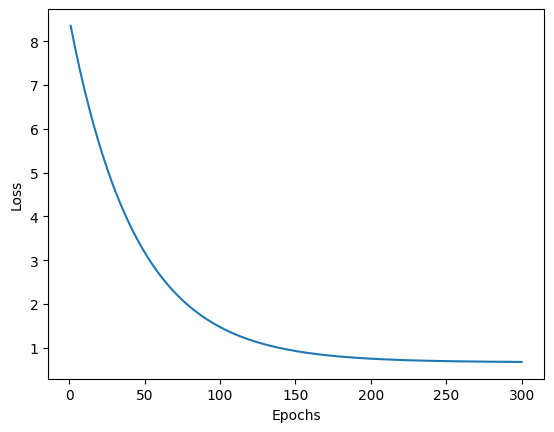

Text(0.5, 1.0, 'Biases vs. Epochs')

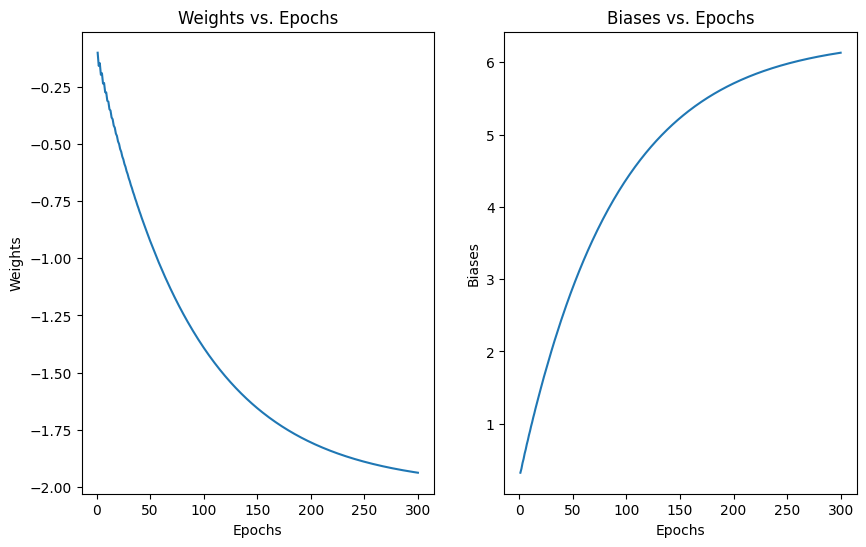

In [ ]:
epochs = 300
learning_rate = 0.03
loss_history, w_history, b_history = trainNN(n, xs, ys, epochs, learning_rate)
epoch_array = np.arange(1, epochs+1)
plt.plot(epoch_array, loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].plot(epoch_array, w_history)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Weights')
ax[0].set_title('Weights vs. Epochs')
ax[1].plot(epoch_array, b_history)
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Biases')
ax[1].set_title('Biases vs. Epochs')

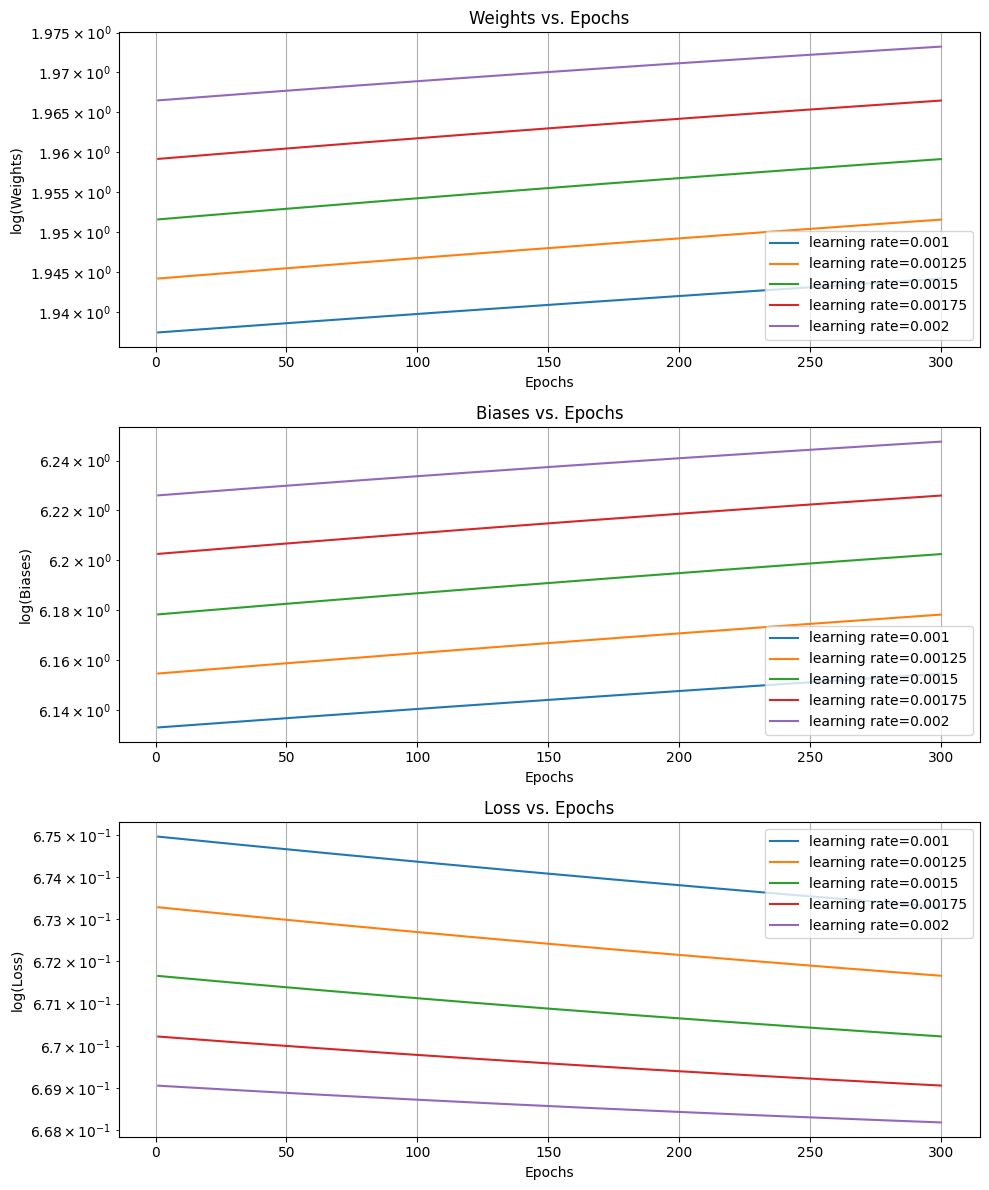

In [ ]:
loss_histories = []
weight_histories = []
bias_histories = []
epochs = 300
learning_rates = np.linspace(0.001, 0.002, 5)

for lr in learning_rates:
  loss_history, w_history, b_history = trainNN(MLP(1, [1]), xs, ys, epochs, lr)
  weight_histories.append(w_history)
  bias_histories.append(b_history)
  loss_histories.append(loss_history)


fig, ax = plt.subplots(3, 1, figsize=(10, 12))

for lr, w_history, b_history, loss_history in zip(learning_rates, weight_histories, bias_histories, loss_histories):
    w_history = np.array(w_history)
    b_history = np.array(b_history)
    loss_history = np.array(loss_history)

    ax[0].plot(epoch_array, np.abs(w_history),label=f'learning rate={lr}')
    ax[1].plot(epoch_array, b_history, label=f'learning rate={lr}')
    ax[2].plot(epoch_array, loss_history, label=f'learning rate={lr}')

ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[2].set_yscale('log')

ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('log(Weights)')
ax[0].set_title('Weights vs. Epochs')
ax[0].grid(True)


ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('log(Biases)')
ax[1].set_title('Biases vs. Epochs')
ax[1].grid(True)

ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('log(Loss)')
ax[2].set_title('Loss vs. Epochs')
ax[2].grid(True)

ax[0].legend()
ax[1].legend()
ax[2].legend()


plt.tight_layout()
plt.show()
